=== Dynamic Quantum Lyapunov Synthesis with BH at Every Step ===

=== Decision step 1/40 ===
   Updated parameter ranges after BH:
      alpha: [8.048, 11.570] (width=3.522)
      beta: [0.304, 1.636] (width=1.333)
      k: [1.194, 5.980] (width=4.786)
      theta2: [17.190, 20.963] (width=3.773)
      theta4: [0.117, 3.812] (width=3.694)
   Selected params: s=0110000000, alpha=9.222, beta=1.192, k=1.194, theta2=17.190, theta4=0.117, J=68.5785
   State at end of interval: [ 0.10456566 -0.0746703   0.15497685 -0.14742978  0.00361554]
   Consensus error ||Lx||_2 = 8.584e-01

=== Decision step 2/40 ===
   Updated parameter ranges after BH:
      alpha: [8.300, 10.032] (width=1.732)
      beta: [0.506, 1.394] (width=0.888)
      k: [1.290, 5.171] (width=3.881)
      theta2: [19.263, 20.712] (width=1.449)
      theta4: [0.135, 2.485] (width=2.350)
   Selected params: s=0000000000, alpha=8.300, beta=0.506, k=1.290, theta2=19.263, theta4=0.135, J=0.0735
   State at end of interval: [ 0.007786

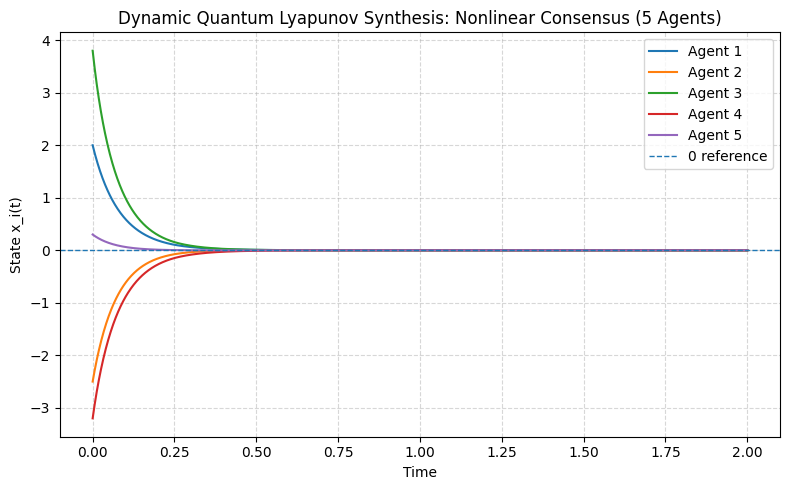

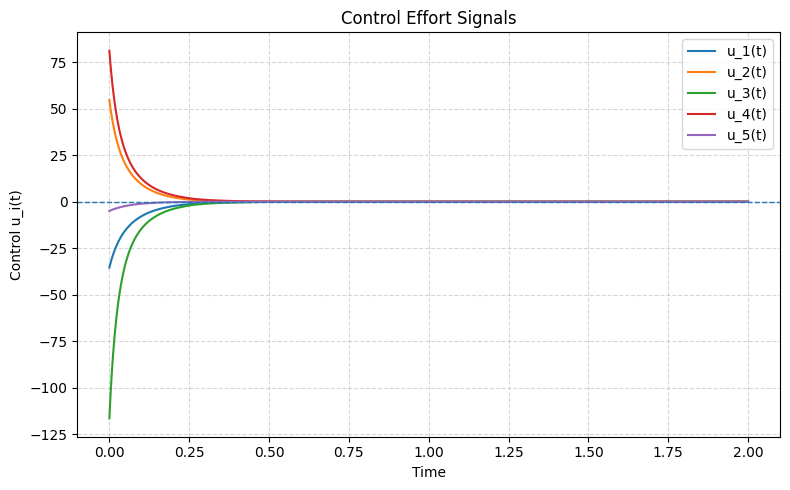


Final states at t = 2.0000:
  Agent 1: x_1(T) = 1.942920e-08
  Agent 2: x_2(T) = 2.054201e-08
  Agent 3: x_3(T) = 1.739707e-08
  Agent 4: x_4(T) = 1.402400e-08
  Agent 5: x_5(T) = 1.537244e-08

Final consensus error:
  ||Lx(T)||_2 = 7.51498345553002e-09

Final parameter ranges after last BH:
  alpha: [8.540, 8.564]
  beta: [0.875, 0.953]
  k: [1.585, 2.689]
  theta2: [20.552, 20.557]
  theta4: [0.163, 0.319]


In [4]:
import numpy as np
from itertools import product
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import Estimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import VarQITE
from qiskit_algorithms.time_evolvers import TimeEvolutionProblem
from qiskit_algorithms.time_evolvers.variational import ImaginaryMcLachlanPrinciple

# ============================================================
# GLOBAL CONFIGURATION (EASY TO MODIFY)
# ============================================================

VERBOSE = False  # set True for detailed debug prints

# ----- Multi-Agent System -----
N_AGENTS = 5

# Ring topology adjacency matrix
A = np.array([
    [0, 1, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1],
    [1, 0, 0, 1, 0],
], dtype=float)

D = np.diag(A.sum(axis=1))
L = D - A

# Initial condition for the MAS (also used as BH reference x0 at k=0)
X0_GLOBAL = np.array([2.0, -2.5, 3.8, -3.2, 0.3])

# ----- Lyapunov-aware cost (both for BH and Stage 2) -----
T_HORIZON_COST = 0.25     # short horizon for cost evaluation
N_TIME_COST = 150         # time discretization in horizon
W_Z = 1.0                 # weight on disagreement ||Lx||^2
W_U = 0.1                 # weight on control ||u||^2
W_LYAP = 1.0              # weight on Lyapunov-violation penalty

# ----- Global parameter ranges (Stage 1 initial box) -----
PARAM_NAMES = ["alpha", "beta", "k", "theta2", "theta4"]
# initial global min/max per parameter
P_MIN_GLOBAL = np.array([0.0, 0.0, 0.0, 0.0, 0.0])
P_MAX_GLOBAL = np.array([50.0, 2.0, 50.0, 25.0, 25.0])

# ----- Stage 1: Black Hole (BH) metaheuristic -----
BH_POP_SIZE = 20          # number of stars
BH_MAX_ITERS = 200        # max BH iterations per decision step
BH_FREEZE_WIDTH = 5.0     # freeze a parameter when max-min <= this

# ----- Stage 2: Dynamic quantum Lyapunov synthesis -----
T_TOTAL = 10.0             # maximum total simulation time (safety cap)
DT_DECISION = 0.25        # quantum decision interval
QITE_TAU = 3.0
QITE_STEPS = 60
QITE_REPS = 2
QITE_SEED_BASE = 42       # base seed; we add k_step

# Stopping criterion for consensus:
# error = ||L x||_2; stop when <= CONS_TOL
CONS_TOL = 1e-8

# Training sample factor (for Hamiltonian fit)
TRAIN_SAMPLE_FACTOR = 4   # multiply n_basis by this
MIN_TRAIN_SAMPLES = 64    # minimum training samples
TOP_K_CANDIDATES = 32     # evaluate true cost on top-K bitstrings (by probability)

# ----- Bit allocation rules (given final width w_i = max-min) -----
# Example heuristic:
#   if width <= 5   -> 2 bits
#   elif width <=20 -> 3 bits
#   else            -> 4 bits
BIT_WIDTH_THRESHOLDS = [5.0, 20.0]
BIT_ALLOCATION = [2, 3, 4]    # corresponding bits
MAX_BITS_PER_PARAM = 4        # safety cap

# ============================================================
# 1) Closed-loop dynamics and Lyapunov functions
# ============================================================

def closed_loop_dynamics(t, x, alpha, beta, k_gain):
    """
    Closed-loop dynamics for the scalar MAS:

        dot x_i = x_i + x_i^3 + u_i
        u_i = -alpha*x_i - beta*x_i^3 - k * sum_{j in N_i} (x_i - x_j)

    => dot x = (1-alpha)*x + (1-beta)*x^3 - k L x
    """
    x = np.asarray(x)
    local_drift = x + x**3
    control_u = -alpha * x - beta * x**3 - k_gain * (L @ x)
    dxdt = local_drift + control_u
    return dxdt


def control_law(x, alpha, beta, k_gain):
    """
    Compute control u(t) for a given state x and gains (alpha, beta, k).
    x can be shape (N,) or (N, T).
    """
    x = np.asarray(x)
    if x.ndim == 1:
        return -alpha * x - beta * x**3 - k_gain * (L @ x)
    else:
        return -alpha * x - beta * x**3 - k_gain * (L @ x)


def lyapunov_V(x, theta2, theta4):
    """
    V(x) = (theta2/2) * ||x||^2 + (theta4/4) * sum_i x_i^4
    """
    x = np.asarray(x)
    return 0.5 * theta2 * np.sum(x**2) + 0.25 * theta4 * np.sum(x**4)


def lyapunov_dVdt(x, dxdt, theta2, theta4):
    """
    dV/dt = sum_i (dV/dx_i * dx_i/dt)
    where dV/dx_i = theta2 * x_i + theta4 * x_i^3
    """
    x = np.asarray(x)
    dxdt = np.asarray(dxdt)
    dVdx = theta2 * x + theta4 * x**3
    return float(np.dot(dVdx, dxdt))


def simulate_horizon_cost(x0,
                          alpha, beta, k_gain, theta2, theta4,
                          t_horizon=T_HORIZON_COST,
                          n_time=N_TIME_COST,
                          w_z=W_Z,
                          w_u=W_U,
                          w_lyap=W_LYAP):
    """
    Short-horizon Lyapunov-aware cost from x0.
    This is the core black-box cost used both in Stage 1 (BH) and Stage 2.
    """
    t_span = (0.0, t_horizon)
    t_eval = np.linspace(t_span[0], t_span[1], n_time)

    def dyn(t, x):
        return closed_loop_dynamics(t, x, alpha, beta, k_gain)

    sol = solve_ivp(dyn, t_span, x0, t_eval=t_eval,
                    method="RK45", rtol=1e-6, atol=1e-8)

    if not sol.success:
        return 1e6

    t = sol.t
    X = sol.y  # shape (N, len(t))

    # Blow-up check
    if np.any(np.abs(X) > 1e3):
        return 1e6

    # Disagreement and control
    Z = L @ X
    U = control_law(X, alpha, beta, k_gain)

    z_norm_sq = np.sum(Z**2, axis=0)
    u_norm_sq = np.sum(U**2, axis=0)
    integrand_perf = w_z * z_norm_sq + w_u * u_norm_sq

    # Lyapunov derivative along the trajectory
    dVdt_vals = []
    for idx, tt in enumerate(t):
        x_t = X[:, idx]
        dxdt_t = dyn(tt, x_t)
        dVdt_vals.append(lyapunov_dVdt(x_t, dxdt_t, theta2, theta4))
    dVdt_vals = np.array(dVdt_vals)

    lyap_violation = np.maximum(0.0, dVdt_vals)   # only penalize increases
    integrand_lyap = lyap_violation**2

    # Integrate with trapezoidal rule
    J_perf = float(np.trapz(integrand_perf, t))
    J_lyap = float(np.trapz(integrand_lyap, t))
    J_total = J_perf + w_lyap * J_lyap

    return J_total


# ============================================================
# 2) Stage 1: Black Hole (BH) range calibration (per step)
# ============================================================

def bh_initialize_population(p_min_init, p_max_init):
    """
    Initialize BH star population uniformly in the given box [p_min_init, p_max_init].
    Returns stars of shape (BH_POP_SIZE, n_params).
    """
    n_params = len(PARAM_NAMES)
    stars = np.random.uniform(
        low=p_min_init,
        high=p_max_init,
        size=(BH_POP_SIZE, n_params)
    )
    return stars


def bh_evaluate_population(stars, x0):
    """
    Evaluate black-box cost for each star.
    stars: (BH_POP_SIZE, n_params)
    """
    costs = np.zeros(len(stars))
    for i, p in enumerate(stars):
        alpha, beta, k_gain, theta2, theta4 = p
        costs[i] = simulate_horizon_cost(x0, alpha, beta, k_gain, theta2, theta4)
    return costs


def bh_range_calibration(p_min_init, p_max_init, x0):
    """
    Stage 1: simplified Black Hole metaheuristic to shrink parameter ranges
    around *current* state x0 at a given decision step.

    - Starts from [p_min_init, p_max_init].
    - Shrinks per-parameter ranges based on star population.
    - Freezes a parameter when width <= BH_FREEZE_WIDTH.
    Returns:
        p_min_final, p_max_final    (arrays of length n_params)
    """
    # You can make this seed depend on step if you want more randomness
    np.random.seed(0)

    n_params = len(PARAM_NAMES)
    stars = bh_initialize_population(p_min_init, p_max_init)
    active = np.ones(n_params, dtype=bool)   # whether parameter i is still being shrunk
    p_min = p_min_init.copy()
    p_max = p_max_init.copy()

    for it in range(BH_MAX_ITERS):
        # Evaluate cost
        costs = bh_evaluate_population(stars, x0)
        best_idx = np.argmin(costs)
        black_hole = stars[best_idx].copy()
        best_cost = costs[best_idx]

        if VERBOSE:
            print(f"[BH] Iter {it+1}/{BH_MAX_ITERS}, best_cost={best_cost:.4e}")

        # Move other stars toward black hole (simplified BH update)
        for i in range(BH_POP_SIZE):
            if i == best_idx:
                continue
            # Only move active coordinates
            rand_vec = np.random.rand(np.sum(active))
            stars[i, active] = stars[i, active] + rand_vec * (black_hole[active] - stars[i, active])

        # Clip to current ranges
        for j in range(n_params):
            stars[:, j] = np.clip(stars[:, j], p_min[j], p_max[j])

        # Update parameter ranges based on current star population
        for j in range(n_params):
            if not active[j]:
                continue
            cur_min = np.min(stars[:, j])
            cur_max = np.max(stars[:, j])
            # Never go outside global bounds
            p_min[j] = max(cur_min, P_MIN_GLOBAL[j])
            p_max[j] = min(cur_max, P_MAX_GLOBAL[j])
            width = p_max[j] - p_min[j]

            if width <= BH_FREEZE_WIDTH:
                # Freeze this parameter
                active[j] = False
                if VERBOSE:
                    print(f"[BH] Param {PARAM_NAMES[j]} frozen with range [{p_min[j]:.3f}, {p_max[j]:.3f}]")

        # If all frozen, break
        if not np.any(active):
            if VERBOSE:
                print("[BH] All parameters frozen, stopping BH for this step.")
            break

    if VERBOSE:
        print("[BH] Final ranges for this step:")
        for name, mn, mx in zip(PARAM_NAMES, p_min, p_max):
            print(f"   {name}: [{mn:.3f}, {mx:.3f}] width={mx-mn:.3f}")

    return p_min, p_max


# ============================================================
# 3) Bit allocation & parameter encoding
# ============================================================

def choose_bits_for_width(width):
    """
    Given a width, choose number of bits based on BIT_WIDTH_THRESHOLDS & BIT_ALLOCATION.
    """
    if width <= BIT_WIDTH_THRESHOLDS[0]:
        return min(BIT_ALLOCATION[0], MAX_BITS_PER_PARAM)
    elif width <= BIT_WIDTH_THRESHOLDS[1]:
        return min(BIT_ALLOCATION[1], MAX_BITS_PER_PARAM)
    else:
        return min(BIT_ALLOCATION[2], MAX_BITS_PER_PARAM)


def allocate_bits_for_parameters(p_min, p_max):
    """
    For each parameter i, compute width and choose bits.
    Returns bits_per_param (list of ints), and total number of qubits.
    """
    widths = p_max - p_min
    bits_per_param = []
    for w in widths:
        bits_per_param.append(choose_bits_for_width(w))
    num_qubits = int(np.sum(bits_per_param))
    if VERBOSE:
        print("[Bits] Allocation per param (this step):")
        for name, w, b in zip(PARAM_NAMES, widths, bits_per_param):
            print(f"   {name}: width={w:.3f}, bits={b}")
        print(f"   Total qubits = {num_qubits}")
    return bits_per_param, num_qubits


def decode_bitstring_to_params(bitstr, p_min, p_max, bits_per_param):
    """
    Decode a bitstring to continuous parameters using the per-parameter ranges and bits.
    For each parameter i:
      - take its n_i bits
      - interpret as integer v in [0, 2^{n_i}-1]
      - map to [p_min[i], p_max[i]] linearly
    """
    assert len(bitstr) == int(np.sum(bits_per_param))
    p_min = np.asarray(p_min)
    p_max = np.asarray(p_max)
    params = []

    idx = 0
    for i, n_bits in enumerate(bits_per_param):
        bits_i = bitstr[idx: idx + n_bits]
        idx += n_bits
        v = int(bits_i, 2)
        levels = 2**n_bits - 1
        if levels <= 0:
            p_val = p_min[i]
        else:
            p_val = p_min[i] + (p_max[i] - p_min[i]) * (v / levels)
        params.append(p_val)

    return params  # [alpha, beta, k, theta2, theta4]


# ============================================================
# 4) Diagonal Pauli basis & Hamiltonian fit (sampled)
# ============================================================

def build_diagonal_pauli_basis(num_qubits):
    """
    Diagonal Pauli basis: {I...I, all single Z_i, all pairwise Z_i Z_j}.
    """
    n = num_qubits
    paulis = []

    # Identity
    paulis.append("I" * n)

    # Single Z terms
    for i in range(n):
        s = ["I"] * n
        s[i] = "Z"
        paulis.append("".join(s))

    # Pairwise ZZ terms
    for i in range(n):
        for j in range(i + 1, n):
            s = ["I"] * n
            s[i] = "Z"
            s[j] = "Z"
            paulis.append("".join(s))

    return paulis  # length = 1 + n + n(n-1)/2


def eigenvalue_of_pauli_on_bitstring(pauli_label, bitstr):
    """
    Eigenvalue of a diagonal Pauli (I/Z only) on |bitstr>.
    """
    n = len(bitstr)
    assert len(pauli_label) == n
    bits = [int(b) for b in bitstr]
    eig = 1.0
    # Qiskit convention: rightmost bit = qubit 0
    for j in range(n):
        p = pauli_label[n - 1 - j]      # char index in label
        if p == 'Z':
            eig *= (1.0 if bits[-1 - j] == 0 else -1.0)
        elif p == 'I':
            continue
        else:
            raise ValueError("Non-diagonal Pauli encountered.")
    return eig


def sample_bitstrings(num_qubits, num_samples):
    """
    Uniformly sample bitstrings of length num_qubits.
    """
    bitstrings = set()
    while len(bitstrings) < num_samples:
        s = ''.join(np.random.choice(['0', '1'], size=num_qubits))
        bitstrings.add(s)
    return list(bitstrings)


def fit_diagonal_hamiltonian_sampled(x0, p_min, p_max, bits_per_param,
                                     paulis, num_qubits):
    """
    Fit H = sum_k h_k P_k using a sampled subset of bitstrings.
    We:
      - sample bitstrings
      - evaluate true black-box cost on those bitstrings
      - solve least-squares M h ≈ J to get coefficients h
    """
    n_basis = len(paulis)
    num_samples = max(TRAIN_SAMPLE_FACTOR * n_basis, MIN_TRAIN_SAMPLES)

    if VERBOSE:
        print(f"[H-fit] num_qubits={num_qubits}, n_basis={n_basis}, num_samples={num_samples}")

    sampled_bitstrings = sample_bitstrings(num_qubits, num_samples)

    M = np.zeros((num_samples, n_basis), dtype=float)
    J_vec = np.zeros(num_samples, dtype=float)

    for idx, s in enumerate(sampled_bitstrings):
        # decode s -> parameters
        alpha, beta, k_gain, theta2, theta4 = decode_bitstring_to_params(
            s, p_min, p_max, bits_per_param
        )
        J = simulate_horizon_cost(x0, alpha, beta, k_gain, theta2, theta4)
        J_vec[idx] = J

        # Fill row of M with eigenvalues of each Pauli on |s>
        for k, P in enumerate(paulis):
            M[idx, k] = eigenvalue_of_pauli_on_bitstring(P, s)

    # Solve least squares
    h, *_ = np.linalg.lstsq(M, J_vec, rcond=None)

    if VERBOSE:
        print("[H-fit] First few coefficients:")
        for coef, P in list(zip(h, paulis))[:10]:
            print(f"   {P}: {coef:.6f}")

    H = SparsePauliOp.from_list(list(zip(paulis, h)))
    return H


# ============================================================
# 5) QITE-based search for best bitstring at one decision step
# ============================================================

def qite_select_best_bitstring(H, x0, p_min, p_max, bits_per_param,
                               tau=QITE_TAU,
                               steps=QITE_STEPS,
                               reps=QITE_REPS,
                               seed=0):
    """
    Run VarQITE on H, obtain final state, and select the best bitstring
    according to the TRUE black-box cost (not the fitted Hamiltonian).

    We:
      - run QITE
      - get final statevector and probabilities
      - sort bitstrings by probability
      - evaluate true cost on top-K candidates
      - pick the one with the smallest true cost
    """
    np.random.seed(seed)
    num_qubits = int(np.sum(bits_per_param))

    # Ansatz
    ansatz = EfficientSU2(num_qubits, reps=reps, entanglement='linear')
    n_params = ansatz.num_parameters
    if VERBOSE:
        print(f"[QITE] num_qubits={num_qubits}, ansatz params={n_params}")

    init_params = 0.02 * np.random.randn(n_params)

    est = Estimator()
    principle = ImaginaryMcLachlanPrinciple()
    varqite = VarQITE(
        ansatz=ansatz,
        initial_parameters=init_params,
        variational_principle=principle,
        estimator=est,
        num_timesteps=steps,
    )

    problem = TimeEvolutionProblem(hamiltonian=H, time=tau)
    result = varqite.evolve(problem)

    final_circ = result.evolved_state
    sv = Statevector.from_instruction(final_circ)
    probs = sv.probabilities_dict()

    # Sort bitstrings by probability
    sorted_items = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    candidates = sorted_items[:min(TOP_K_CANDIDATES, len(sorted_items))]

    best_s, best_J = None, float('inf')

    if VERBOSE:
        print("[QITE] Evaluating true cost on candidates:")

    for s, p_prob in candidates:
        alpha, beta, k_gain, theta2, theta4 = decode_bitstring_to_params(
            s, p_min, p_max, bits_per_param
        )
        J = simulate_horizon_cost(x0, alpha, beta, k_gain, theta2, theta4)
        if VERBOSE:
            print(f"   s={s}, p_prob={p_prob:.4f}, J={J:.4f}")
        if J < best_J:
            best_s, best_J = s, J

    energy = est.run([final_circ], [H]).result().values[0]
    if VERBOSE:
        print(f"[QITE] Best bitstring {best_s} with J={best_J:.4f}, <H>={energy:.4f}")

    return best_s, best_J


# ============================================================
# 6) Full loop: BH at every step + dynamic QITE + early stopping
# ============================================================

def dynamic_quantum_lyapunov_synthesis_with_repeated_BH():
    """
    Full algorithm:
      - Maintain current parameter ranges [p_min_curr, p_max_curr].
      - At each decision step k:
          * Stage 1: run BH on current ranges with x_k -> new ranges.
          * Decide bits_per_param, build Pauli basis.
          * Fit diagonal H(b; x_k) from sampled bitstrings (no full lookup table).
          * Run QITE, choose best bitstring via true cost.
          * Apply resulting parameters for closed-loop dynamics over [t_k, t_{k+1}].
          * Check consensus error ||L x_{k+1}||_2 <= CONS_TOL; if so, stop.
      - Safety cap: do at most floor(T_TOTAL / DT_DECISION) decision steps.
    """
    print("=== Dynamic Quantum Lyapunov Synthesis with BH at Every Step ===")

    # Initial ranges
    p_min_curr = P_MIN_GLOBAL.copy()
    p_max_curr = P_MAX_GLOBAL.copy()

    # Initial state
    x_current = X0_GLOBAL.copy()

    # Global trajectories
    t_global = [0.0]
    X_global = [x_current.copy()]
    U_global = [control_law(x_current, 0.0, 0.0, 0.0)]  # dummy first control

    alpha_hist = []
    beta_hist = []
    k_hist = []
    theta2_hist = []
    theta4_hist = []

    max_steps = int(T_TOTAL / DT_DECISION)

    for k_step in range(max_steps):
        print(f"\n=== Decision step {k_step+1}/{max_steps} ===")
        if VERBOSE:
            print(f"   Current state x_k = {x_current}")

        # ---------------------------------------------------
        # Stage 1 (this step): BH range calibration around x_current
        # ---------------------------------------------------
        p_min_step, p_max_step = bh_range_calibration(p_min_curr, p_max_curr, x_current)
        p_min_curr = p_min_step
        p_max_curr = p_max_step

        print("   Updated parameter ranges after BH:")
        for name, mn, mx in zip(PARAM_NAMES, p_min_curr, p_max_curr):
            print(f"      {name}: [{mn:.3f}, {mx:.3f}] (width={mx-mn:.3f})")

        # Bit allocation for this step
        bits_per_param, num_qubits = allocate_bits_for_parameters(p_min_curr, p_max_curr)
        paulis = build_diagonal_pauli_basis(num_qubits)

        # ---------------------------------------------------
        # Stage 2 (this step): QITE-based dynamic Lyapunov synthesis
        # ---------------------------------------------------
        # 1) Fit diagonal Hamiltonian H(b; x_k) from sampled bitstrings
        H = fit_diagonal_hamiltonian_sampled(
            x_current, p_min_curr, p_max_curr, bits_per_param,
            paulis, num_qubits
        )

        # 2) QITE to find good bitstring (no full lookup table)
        best_s, best_J = qite_select_best_bitstring(
            H, x_current, p_min_curr, p_max_curr, bits_per_param,
            tau=QITE_TAU,
            steps=QITE_STEPS,
            reps=QITE_REPS,
            seed=QITE_SEED_BASE + k_step
        )

        alpha, beta, k_gain, theta2, theta4 = decode_bitstring_to_params(
            best_s, p_min_curr, p_max_curr, bits_per_param
        )
        print(f"   Selected params: s={best_s}, "
              f"alpha={alpha:.3f}, beta={beta:.3f}, k={k_gain:.3f}, "
              f"theta2={theta2:.3f}, theta4={theta4:.3f}, J={best_J:.4f}")

        alpha_hist.append(alpha)
        beta_hist.append(beta)
        k_hist.append(k_gain)
        theta2_hist.append(theta2)
        theta4_hist.append(theta4)

        # 3) Integrate true closed-loop system on [t_k, t_{k+1}] with chosen parameters
        t_start = t_global[-1]
        t_end = t_start + DT_DECISION
        t_span = (t_start, t_end)
        t_eval = np.linspace(t_start, t_end, 200)

        def dyn_interval(t, x):
            return closed_loop_dynamics(t, x, alpha, beta, k_gain)

        sol = solve_ivp(dyn_interval, t_span, x_current, t_eval=t_eval,
                        method="RK45", rtol=1e-6, atol=1e-8)

        if not sol.success:
            print("   Integration failed in interval:", sol.message)
            break

        t_local = sol.t
        X_local = sol.y  # shape (N_AGENTS, len(t_local))
        U_local = control_law(X_local, alpha, beta, k_gain)  # shape (N_AGENTS, len(t_local))

        # Append to global trajectory (skip first point to avoid duplication)
        if k_step == 0 and len(t_global) == 1:
            t_global = list(t_local)
            X_global = [X_local[:, i] for i in range(X_local.shape[1])]
            U_global = [U_local[:, i] for i in range(U_local.shape[1])]
        else:
            t_global.extend(list(t_local[1:]))
            X_global.extend([X_local[:, i] for i in range(1, X_local.shape[1])])
            U_global.extend([U_local[:, i] for i in range(1, U_local.shape[1])])

        x_current = X_local[:, -1].copy()
        cons_err = np.linalg.norm(L @ x_current, 2)
        print(f"   State at end of interval: {x_current}")
        print(f"   Consensus error ||Lx||_2 = {cons_err:.3e}")

        # Early stopping criterion
        if cons_err <= CONS_TOL:
            print("   Consensus error below tolerance; stopping simulation.")
            break

    # Convert global trajectories to arrays
    t_global = np.array(t_global)
    X_global = np.array(X_global).T   # shape (N_AGENTS, len(t_global))
    U_global = np.array(U_global).T   # shape (N_AGENTS, len(t_global))

    return (t_global, X_global, U_global,
            alpha_hist, beta_hist, k_hist, theta2_hist, theta4_hist,
            p_min_curr, p_max_curr)


# ============================================================
# 7) Run and plot
# ============================================================

if __name__ == "__main__":
    (t, X, U,
     alpha_hist, beta_hist, k_hist, theta2_hist, theta4_hist,
     p_min_final, p_max_final) = dynamic_quantum_lyapunov_synthesis_with_repeated_BH()

    # Plot agent states over time
    plt.figure(figsize=(8, 5))
    for i in range(N_AGENTS):
        plt.plot(t, X[i, :], label=f"Agent {i+1}")
    plt.axhline(0.0, linestyle="--", linewidth=1, label="0 reference")
    plt.xlabel("Time")
    plt.ylabel("State x_i(t)")
    plt.title("Dynamic Quantum Lyapunov Synthesis: Nonlinear Consensus (5 Agents)")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    # Plot control effort (per agent)
    plt.figure(figsize=(8, 5))
    for i in range(N_AGENTS):
        plt.plot(t, U[i, :], label=f"u_{i+1}(t)")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Control u_i(t)")
    plt.title("Control Effort Signals")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    plt.show()

    print("\nFinal states at t = {:.4f}:".format(t[-1]))
    for i in range(N_AGENTS):
        print(f"  Agent {i+1}: x_{i+1}(T) = {X[i, -1]:.6e}")

    print("\nFinal consensus error:")
    print("  ||Lx(T)||_2 =", np.linalg.norm(L @ X[:, -1], 2))

    print("\nFinal parameter ranges after last BH:")
    for name, mn, mx in zip(PARAM_NAMES, p_min_final, p_max_final):
        print(f"  {name}: [{mn:.3f}, {mx:.3f}]")


=== Classical Baseline Simulation (Fixed Gains) ===
   alpha = 2.0, beta = 2.0, k = 1.0
   Consensus error below 1.0e-08 at t = 7.650000

Final states at t = 7.650000:
  Agent 1: x_1(T) = 1.758183e-05
  Agent 2: x_2(T) = 1.758056e-05
  Agent 3: x_3(T) = 1.757538e-05
  Agent 4: x_4(T) = 1.757345e-05
  Agent 5: x_5(T) = 1.757743e-05

Final consensus error ||Lx(T)||_2 = 9.642e-09


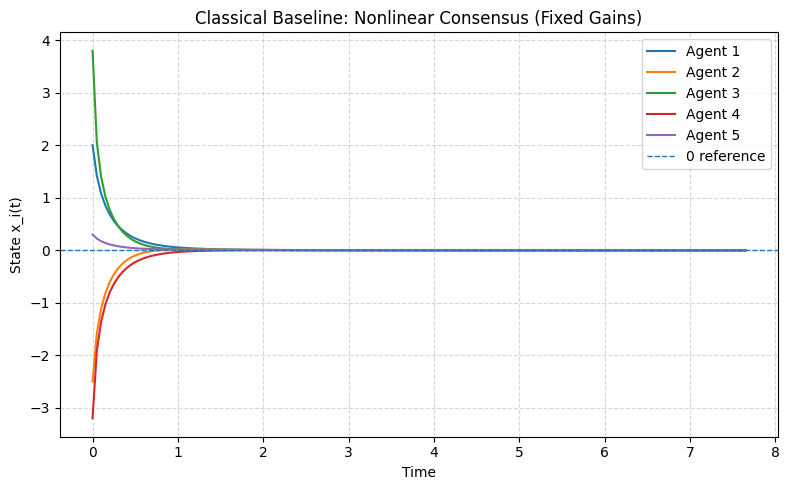

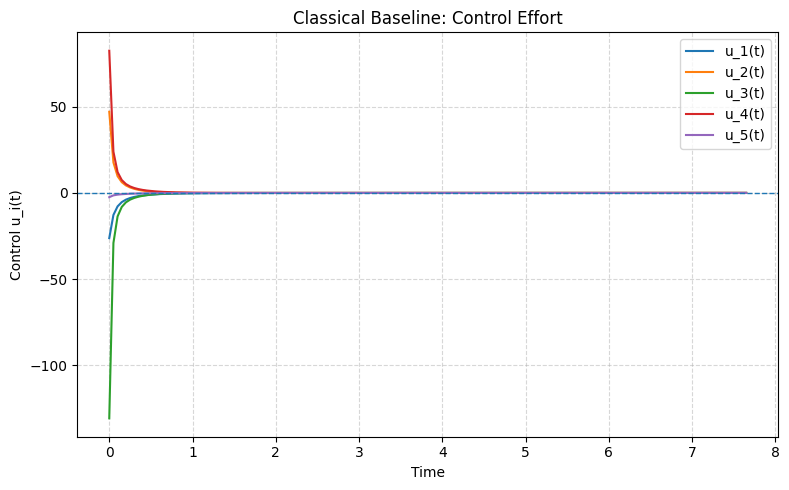

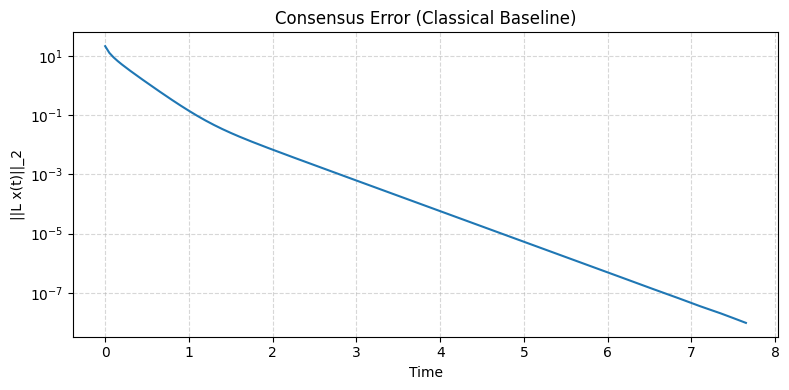

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# USER-CHOSEN PARAMETERS (EDIT HERE)
# ============================================================

# Gains chosen by the user (classical baseline)
ALPHA_USER = 2.0
BETA_USER  = 2.0
K_USER     = 1.0

# Simulation configuration
N_AGENTS   = 5
X0_GLOBAL  = np.array([2.0, -2.5, 3.8, -3.2, 0.3])   # same initial condition
T_TOTAL    = 20.0       # safety cap on total time
DT_STEP    = 0.05      # integration step for plotting (small dt)
CONS_TOL   = 1e-8      # stopping threshold on consensus error ||Lx||_2

# ============================================================
# 1) Graph Laplacian (same ring topology)
# ============================================================

A = np.array([
    [0, 1, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1],
    [1, 0, 0, 1, 0],
], dtype=float)

D = np.diag(A.sum(axis=1))
L = D - A

# ============================================================
# 2) Closed-loop dynamics and control law
# ============================================================

def closed_loop_dynamics(t, x, alpha, beta, k_gain):
    """
    Closed-loop dynamics for the scalar MAS:

        dot x_i = x_i + x_i^3 + u_i
        u_i = -alpha*x_i - beta*x_i^3 - k * sum_{j in N_i} (x_i - x_j)

    => dot x = (1-alpha)*x + (1-beta)*x^3 - k L x
    """
    x = np.asarray(x)
    local_drift = x + x**3
    control_u   = -alpha * x - beta * x**3 - k_gain * (L @ x)
    dxdt        = local_drift + control_u
    return dxdt


def control_law(x, alpha, beta, k_gain):
    """
    Compute control u(t) for a given state x and fixed gains (alpha, beta, k).
    """
    x = np.asarray(x)
    return -alpha * x - beta * x**3 - k_gain * (L @ x)


# ============================================================
# 3) Closed-loop simulation with early stopping
# ============================================================

def simulate_classical_consensus(alpha, beta, k_gain):
    """
    Simulate the nonlinear consensus system with *fixed* gains (alpha, beta, k_gain),
    using piecewise integration and early stopping once ||Lx||_2 <= CONS_TOL.
    """
    print("=== Classical Baseline Simulation (Fixed Gains) ===")
    print(f"   alpha = {alpha}, beta = {beta}, k = {k_gain}")

    # Time grid for integration
    t_full = np.arange(0.0, T_TOTAL + DT_STEP, DT_STEP)

    # We integrate in one shot here, but we will still check for early stopping
    def dyn(t, x):
        return closed_loop_dynamics(t, x, alpha, beta, k_gain)

    sol = solve_ivp(
        dyn,
        (0.0, T_TOTAL),
        X0_GLOBAL,
        t_eval=t_full,
        method="RK45",
        rtol=1e-6,
        atol=1e-8
    )

    if not sol.success:
        print("Integration failed:", sol.message)

    t = sol.t
    X = sol.y  # shape (N_AGENTS, len(t))

    # Compute control and consensus error over time
    U = np.zeros_like(X)
    cons_err = np.zeros_like(t)
    for idx in range(len(t)):
        x_t = X[:, idx]
        U[:, idx] = control_law(x_t, alpha, beta, k_gain)
        cons_err[idx] = np.linalg.norm(L @ x_t, 2)

    # Early stopping: truncate trajectories where error falls below CONS_TOL
    # (take first index where cons_err <= CONS_TOL)
    below_tol = np.where(cons_err <= CONS_TOL)[0]
    if len(below_tol) > 0:
        stop_idx = below_tol[0]
        print(f"   Consensus error below {CONS_TOL:.1e} at t = {t[stop_idx]:.6f}")
        t = t[:stop_idx + 1]
        X = X[:, :stop_idx + 1]
        U = U[:, :stop_idx + 1]
        cons_err = cons_err[:stop_idx + 1]
    else:
        print("   Did not reach consensus tolerance within T_TOTAL.")

    # Final report
    print("\nFinal states at t = {:.6f}:".format(t[-1]))
    for i in range(N_AGENTS):
        print(f"  Agent {i+1}: x_{i+1}(T) = {X[i, -1]:.6e}")
    print("\nFinal consensus error ||Lx(T)||_2 = {:.3e}".format(cons_err[-1]))

    return t, X, U, cons_err


# ============================================================
# 4) Run and plot
# ============================================================

if __name__ == "__main__":
    t, X, U, cons_err = simulate_classical_consensus(ALPHA_USER, BETA_USER, K_USER)

    # --- Plot agent states over time ---
    plt.figure(figsize=(8, 5))
    for i in range(N_AGENTS):
        plt.plot(t, X[i, :], label=f"Agent {i+1}")
    plt.axhline(0.0, linestyle="--", linewidth=1, label="0 reference")
    plt.xlabel("Time")
    plt.ylabel("State x_i(t)")
    plt.title("Classical Baseline: Nonlinear Consensus (Fixed Gains)")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    # --- Plot control inputs over time ---
    plt.figure(figsize=(8, 5))
    for i in range(N_AGENTS):
        plt.plot(t, U[i, :], label=f"u_{i+1}(t)")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Control u_i(t)")
    plt.title("Classical Baseline: Control Effort")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    # --- Plot consensus error over time ---
    plt.figure(figsize=(8, 4))
    plt.semilogy(t, cons_err)
    plt.xlabel("Time")
    plt.ylabel("||L x(t)||_2")
    plt.title("Consensus Error (Classical Baseline)")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.tight_layout()

    plt.show()
